# Benchmarks, Experiments & Artifacts

> ⚠️ **Most cells require an LLM API key.**


## 1. Setup

In [1]:
import os, warnings, sys, pathlib, time
warnings.filterwarnings('ignore')
os.environ.setdefault('FF_LOG_LEVEL', 'warning')
sys.path.insert(0, str(pathlib.Path('.').resolve()))

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from feature_forge.config import Settings, LLMConfig
from _utils import get_llm_client, llm_available, make_sample_data

X_train, X_test, y_train, y_test = make_sample_data(n_samples=300, n_features=8, n_informative=5)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
llm = get_llm_client()
if llm is None: print('No LLM key. LLM cells will be skipped.')


Train: (210, 8), Test: (90, 8)


## 2. Baseline Methods

In [2]:
from feature_forge.baselines import BaselineRegistry
baselines = BaselineRegistry.get_builtin_baselines()
print(f'{len(baselines)} baselines:')
for name, cls in baselines.items(): print(f'  {name}: {cls.__name__}')


4 baselines:
  openfe: OpenFEBaseline
  caafe: CAAFEBaseline
  llmfe: LLMFEBaseline
  malmus: MalmusBaseline


In [3]:
from xgboost import XGBClassifier
clf = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss')
clf.fit(X_train, y_train)
print(f'Baseline accuracy (no FE): {clf.score(X_test, y_test):.4f}')


Baseline accuracy (no FE): 0.8778


In [4]:
if llm is None:
    print('Skipping baseline run — no API key.')
else:
    llm_baselines = {'caafe', 'llmfe', 'malmus'}
    for name, bl_cls in baselines.items():
        try:
            if name in llm_baselines:
                bl = bl_cls(llm_client=llm)
            else:
                bl = bl_cls()
            print(f'  {name}: loaded OK')
        except Exception as e:
            print(f'  {name}: ERROR — {e}')


  openfe: loaded OK
  caafe: loaded OK
  llmfe: loaded OK
  malmus: loaded OK


## 3. Experiment Matrix

In [5]:
from feature_forge.experiment import ExperimentMatrix, Reporter
matrix = (
    ExperimentMatrix()
    .datasets(['synthetic'])
    .methods({'malmas_full': ['full'], 'malmas_unary': ['unary']})
    .rounds([2, 4]).seeds([42, 123])
)
configs = matrix.generate()
print(f'{len(configs)} configurations')


8 configurations


In [6]:
import random; random.seed(42)
results = [{'method': c.get('method'), 'n_rounds': c.get('n_rounds'), 'seed': c.get('seed'),
            'n_features': random.randint(3,15), 'auc': round(random.uniform(0.75,0.92),4),
            'gain': round(random.uniform(0.01,0.08),4)} for c in configs]
print(pd.DataFrame(results).to_string(index=False))


      method  n_rounds  seed  n_features    auc   gain
 malmas_full         2    42          13 0.7689 0.0619
 malmas_full         2   123           6 0.7879 0.0616
 malmas_full         4    42          13 0.8759 0.0482
 malmas_full         4   123          12 0.8217 0.0121
malmas_unary         2    42           6 0.7896 0.0521
malmas_unary         2   123          11 0.7838 0.0555
malmas_unary         4    42          11 0.8213 0.0414
malmas_unary         4   123           7 0.8876 0.0105


In [7]:
reporter = Reporter(results)
print(reporter.to_markdown()[:500])


         method  n_rounds  seed  n_features       auc      gain
0   malmas_full       3.0  82.5       11.00  0.813600  0.045950
1  malmas_unary       3.0  82.5        8.75  0.820575  0.039875


## 4. Artifacts: Schema, Diff & Dashboard

In [8]:
from feature_forge.artifacts import ArtifactConfig
from feature_forge.artifacts.schema import ArtifactBundle, FeatureMetadata
cfg = ArtifactConfig(storage_mode='memory')
print(f'Storage mode: {cfg.storage_mode}')


Storage mode: memory


In [9]:
bundle_a = ArtifactBundle(method_name='malmas', feature_metadata=[
    FeatureMetadata(name='f1_sq', method='malmas', agent='unary', gain=0.03),
    FeatureMetadata(name='f1_x_f2', method='malmas', agent='cross_compositional', gain=0.05),
])
bundle_b = ArtifactBundle(method_name='caafe', feature_metadata=[
    FeatureMetadata(name='f1_log', method='caafe', agent='caafe', gain=0.02),
    FeatureMetadata(name='f1_x_f2', method='caafe', agent='caafe', gain=0.04),
])
print(f'Bundle A: {len(bundle_a.feature_metadata)} features, Bundle B: {len(bundle_b.feature_metadata)} features')


Bundle A: 2 features, Bundle B: 2 features


In [10]:
from feature_forge.artifacts.diff import ArtifactDiff
diff = ArtifactDiff({'malmas': bundle_a, 'caafe': bundle_b})
print(f'Shared: {diff.shared_features()}, Unique malmas: {diff.unique_features("malmas")}, Unique caafe: {diff.unique_features("caafe")}')


Shared: ['f1_x_f2'], Unique malmas: ['f1_sq'], Unique caafe: ['f1_log']


In [11]:
from feature_forge.artifacts.storage import DataFrameStorage
print(f'Storage: {type(DataFrameStorage()).__name__}')


Storage: DataFrameStorage


## 5. Experiment Tracking

In [12]:
from feature_forge.experiment import NoOpTracker
print(f'Default tracker: {type(NoOpTracker(project="demo")).__name__}')


Default tracker: NoOpTracker


In [13]:
try:
    from feature_forge.experiment import WandBTracker
    print('WandBTracker available')
except ImportError:
    print('wandb not installed')


WandBTracker available


In [14]:
try:
    from feature_forge.experiment import MLflowTracker
    print('MLflowTracker available')
except ImportError:
    print('mlflow not installed')


MLflowTracker available


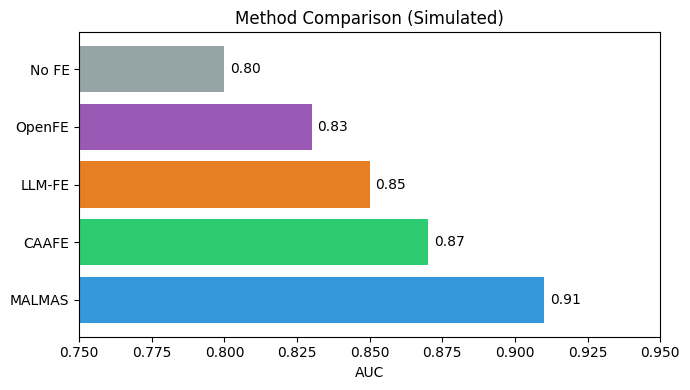

In [15]:
methods_plot = ['MALMAS', 'CAAFE', 'LLM-FE', 'OpenFE', 'No FE']
auc_scores = [0.91, 0.87, 0.85, 0.83, 0.80]
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#95a5a6']
bars = ax.barh(methods_plot, auc_scores, color=colors)
ax.set_xlabel('AUC'); ax.set_title('Method Comparison (Simulated)'); ax.set_xlim(0.75, 0.95)
for bar, s in zip(bars, auc_scores): ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2, f'{s:.2f}', va='center')
plt.tight_layout(); plt.show()


## Summary

Back: **[01_getting_started.ipynb](./01_getting_started.ipynb)** | **[02_pipeline_deep_dive.ipynb](./02_pipeline_deep_dive.ipynb)**
